# Fig. 4 and S2: paired 10x Multiome (RNA + ATAC)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ashford-A/UniVI/blob/main/docs/reproducibility/api/fig4_multiome.ipynb)

The paired RNA + chromatin accessibility analysis (Fig. 4, Supplemental Fig. S2) through UniVI's public API. Model settings follow the archived notebook `UniVI_manuscript_GR-Figure__4__Multiome_paired.ipynb` (Supplemental Table S8); preprocessing follows Supplemental Table S7 using UniVI's preprocessors, so results will be close to, not identical with, the published values.

Data: annotated 10x Multiome PBMCs, 9,631 cells ([Zenodo](https://doi.org/10.5281/zenodo.19581816)).

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q "univi[tutorials]>=1.1"

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import torch

import univi.datasets as uds
from univi import ModalityConfig, TrainingConfig, UniVIConfig, UniVIMultiModalVAE, UniVITrainer
from univi.evaluation import compute_modality_mixing, cross_modal_predict, encode_adata, evaluate_alignment
from univi.preprocessing import ATACPreprocessor, RNAPreprocessor, split_by_label
from univi.utils.seed import set_seed
from univi.workflows import make_loader, stack_embeddings

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
set_seed(0)

C:\Users\ashfo\micromamba\envs\univi-release-050\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
N_EPOCHS = 5000   # archived notebook: 5000 with early stopping (patience 300)
N_HVG = 2000
N_LSI = 100       # archived notebook: 100 LSI components, first component kept

## Data and split

Stratified by `cell_type` with at most 800 training and 100 validation cells per type (80/10 otherwise); the remaining cells form the test set (Supplemental Table S7).

In [4]:
data = uds.pbmc_multiome_10k()
rna, atac = data["rna"], data["atac"]
if "split" in rna.obs:
    splits = {k: np.flatnonzero(rna.obs["split"].to_numpy() == k) for k in ("train", "val", "test")}
else:
    splits = split_by_label(rna.obs["cell_type"], train_fraction=0.8, val_fraction=0.1,
                            train_cap=800, val_cap=100, seed=0)
print({k: len(v) for k, v in splits.items()})

10x-Multiome-Pbmc10k-RNA.h5ad:   0%|          | 0.00/50.7M [00:00<?, ?B/s]

10x-Multiome-Pbmc10k-RNA.h5ad:   2%|▏         | 1.05M/50.7M [00:01<01:10, 704kB/s]

10x-Multiome-Pbmc10k-RNA.h5ad:   4%|▍         | 2.10M/50.7M [00:03<01:12, 667kB/s]

10x-Multiome-Pbmc10k-RNA.h5ad:   6%|▌         | 3.15M/50.7M [00:04<01:09, 689kB/s]

10x-Multiome-Pbmc10k-RNA.h5ad:   8%|▊         | 4.19M/50.7M [00:05<01:03, 728kB/s]

...

10x-Multiome-Pbmc10k-ATAC.h5ad:  99%|█████████▉| 152M/154M [00:49<00:00, 3.13MB/s]

10x-Multiome-Pbmc10k-ATAC.h5ad:  99%|█████████▉| 153M/154M [00:50<00:00, 3.12MB/s]

10x-Multiome-Pbmc10k-ATAC.h5ad: 100%|██████████| 154M/154M [00:50<00:00, 3.34MB/s]

10x-Multiome-Pbmc10k-ATAC.h5ad: 100%|██████████| 154M/154M [00:50<00:00, 3.06MB/s]

{'train': 5777, 'val': 717, 'test': 3137}


In [5]:
rna_prep = RNAPreprocessor(n_hvg=N_HVG, scale=True).fit(rna[splits["train"]])
atac_prep = ATACPreprocessor(n_components=N_LSI, drop_first=False, scale=True).fit(atac[splits["train"]])
parts = {k: {"rna": rna_prep.transform(rna[i]), "atac": atac_prep.transform(atac[i])} for k, i in splits.items()}

In [6]:
cfg = UniVIConfig(
    latent_dim=30, beta=1.25, gamma=4.35, encoder_dropout=0.1, decoder_dropout=0.05,
    kl_anneal_start=50, kl_anneal_end=85, align_anneal_start=75, align_anneal_end=110,
    modalities=[
        ModalityConfig("rna", parts["train"]["rna"].n_vars, [512, 256, 128], [128, 256, 512], likelihood="gaussian"),
        ModalityConfig("atac", parts["train"]["atac"].n_vars, [128, 64], [64, 128], likelihood="gaussian"),
    ],
)
model = UniVIMultiModalVAE(cfg, loss_mode="v1", v1_recon="avg", normalize_v1_terms=True)
UniVITrainer(
    model, make_loader(parts["train"], batch_size=128, shuffle=True, drop_last=True),
    make_loader(parts["val"], batch_size=1024),
    TrainingConfig(n_epochs=N_EPOCHS, batch_size=128, lr=1e-3, weight_decay=1e-4, device=device,
                   early_stopping=True, patience=300, best_epoch_warmup=110, log_every=100),
).fit();

[2026-09-21 14:51:51,488] [UniVITrainer] [INFO] TrainingConfig:


[2026-09-21 14:51:51,489] [UniVITrainer] [INFO]   n_epochs: 5000


[2026-09-21 14:51:51,489] [UniVITrainer] [INFO]   batch_size: 128


[2026-09-21 14:51:51,489] [UniVITrainer] [INFO]   lr: 0.001


[2026-09-21 14:51:51,490] [UniVITrainer] [INFO]   weight_decay: 0.0001


...

Training UniVI:   9%|▉         | 447/5000 [06:41<1:06:25,  1.14it/s, beta=1.250, gamma=4.350, train_loss=838.1211, val_loss=894.8652]

Training UniVI:   9%|▉         | 447/5000 [06:42<1:06:25,  1.14it/s, beta=1.250, gamma=4.350, train_loss=839.2747, val_loss=896.3339]

[2026-09-21 14:58:33,741] [UniVITrainer] [INFO] Early stopping at epoch 448 (best val loss=886.8277, best epoch=148)


Training UniVI:   9%|▉         | 447/5000 [06:42<1:08:17,  1.11it/s, beta=1.250, gamma=4.350, train_loss=839.2747, val_loss=896.3339]


[2026-09-21 14:58:33,746] [UniVITrainer] [INFO] Restored best model from epoch 148 (val loss=886.8277)


## Held-out alignment (Fig. 4)

In [7]:
test = parts["test"]
z_rna = encode_adata(model, test["rna"], modality="rna", device=device, latent="modality_mean")
z_atac = encode_adata(model, test["atac"], modality="atac", device=device, latent="modality_mean")
lab = test["rna"].obs["cell_type"].astype(str).to_numpy()
m = evaluate_alignment(Z1=z_rna, Z2=z_atac, labels_source=lab, labels_target=lab, recall_ks=(1, 10, 50))
pd.Series({
    "FOSCTTM": m["foscttm_mean"],
    "Recall@1": m["recall_at_k"]["1"]["mean"], "Recall@10": m["recall_at_k"]["10"]["mean"],
    "Recall@50": m["recall_at_k"]["50"]["mean"],
    "label transfer acc (RNA to ATAC)": m["label_transfer_acc"],
    "macro-F1, worse direction": m["worst_direction_macro_f1"],
    "modality mixing (k=20)": compute_modality_mixing(np.vstack([z_rna, z_atac]), np.repeat(["rna", "atac"], len(z_rna)), k=20),
}).round(3)

FOSCTTM                             0.048
Recall@1                            0.037
Recall@10                           0.183
Recall@50                           0.425
label transfer acc (RNA to ATAC)    0.963
macro-F1, worse direction           0.722
modality mixing (k=20)              0.192
dtype: float64

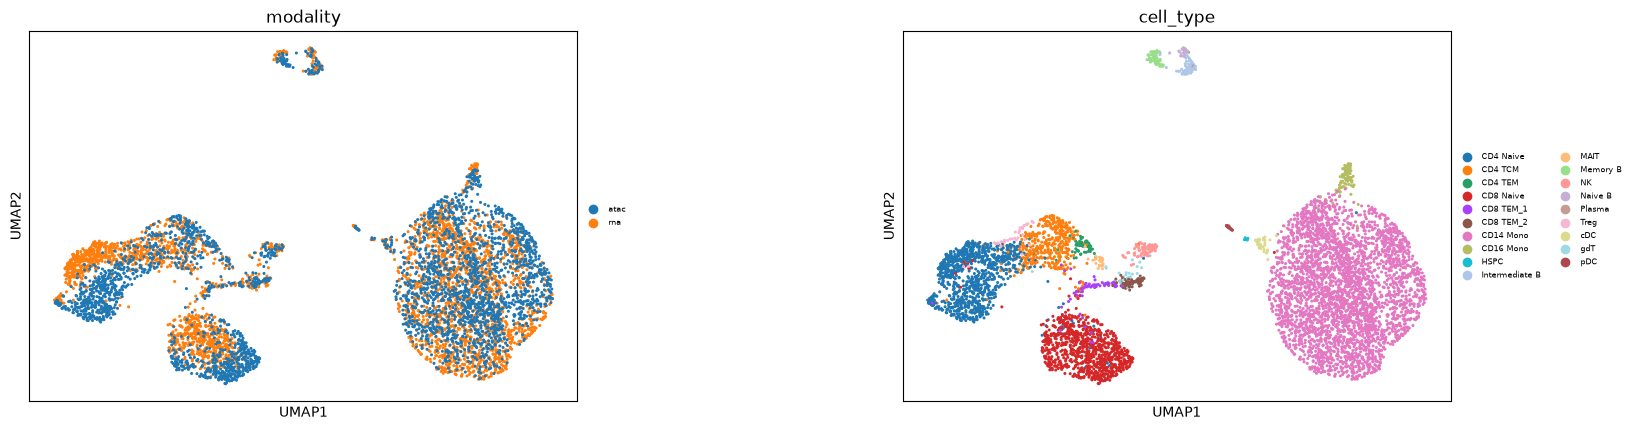

In [8]:
joint = stack_embeddings(model, [("test", "rna", test["rna"]), ("test", "atac", test["atac"])], device=device)
sc.pp.neighbors(joint, use_rep="X_univi", n_neighbors=30)
sc.tl.umap(joint, random_state=0)
sc.pl.umap(joint, color=["modality", "cell_type"], wspace=0.45, legend_fontsize=6)

## Three-dimensional views of the same embedding (Supplemental Fig. S2)

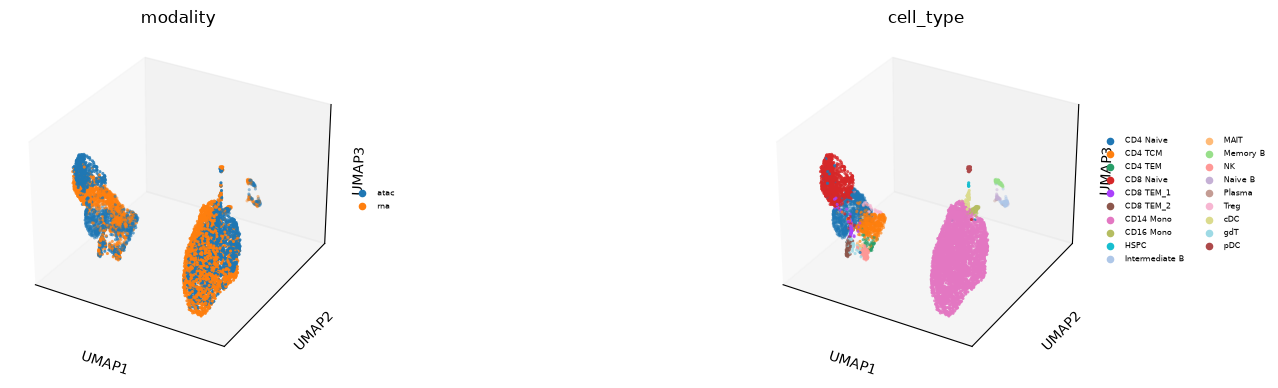

In [9]:
joint3 = joint.copy()
sc.tl.umap(joint3, n_components=3, random_state=0)
sc.pl.umap(joint3, color=["modality", "cell_type"], projection="3d", wspace=0.3, legend_fontsize=6)

## ATAC to RNA prediction of marker genes

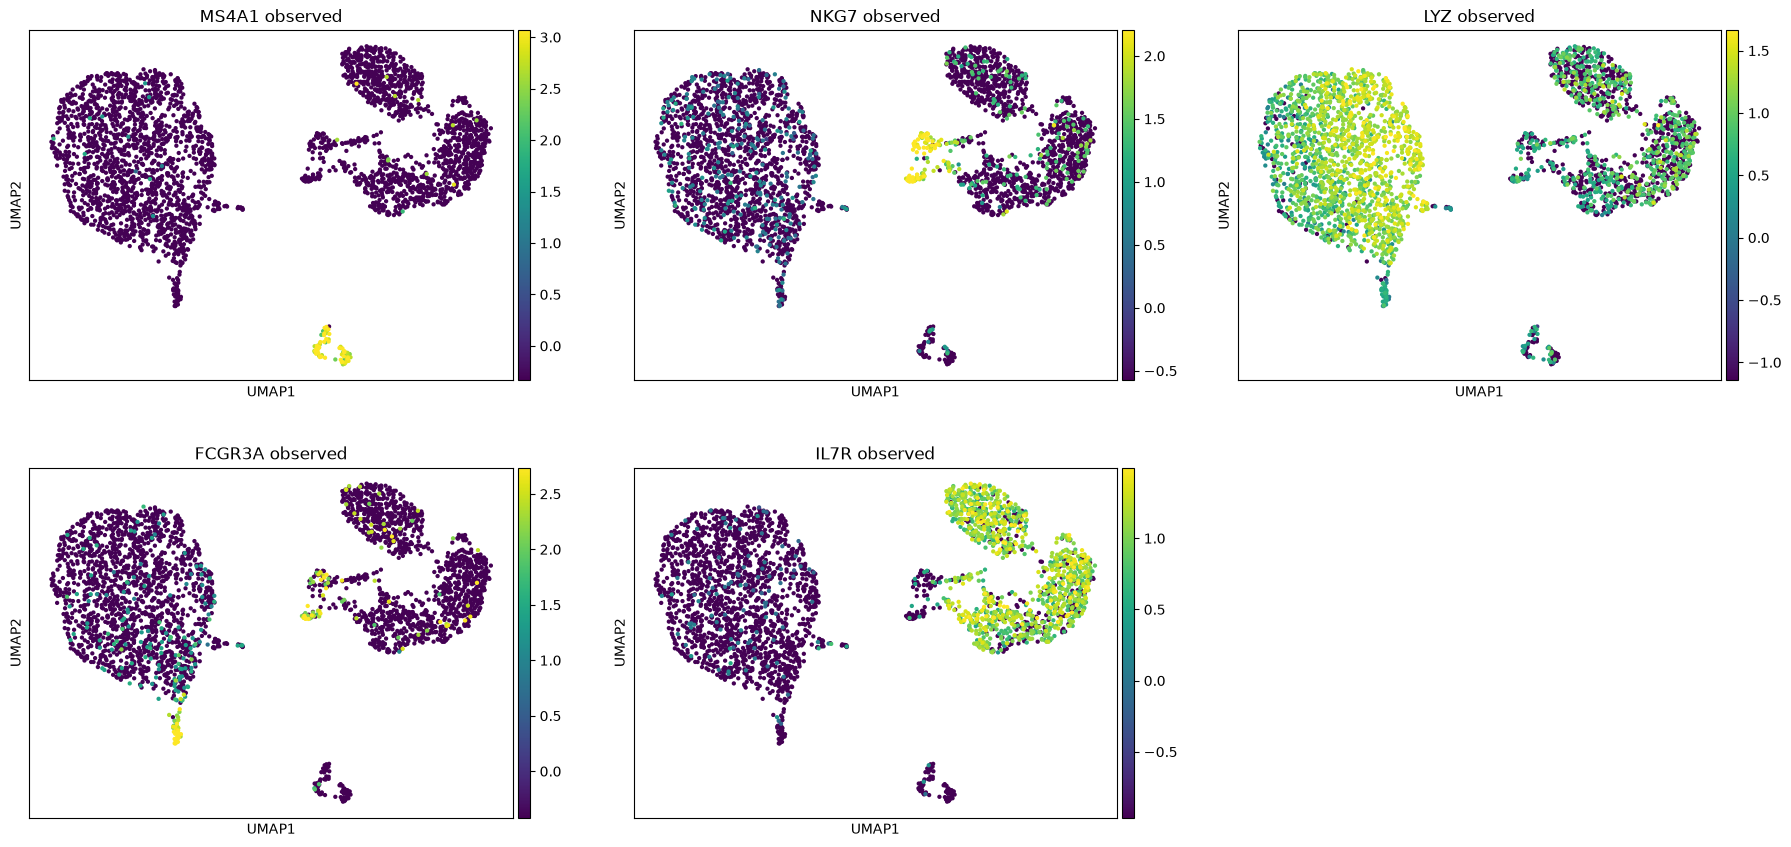

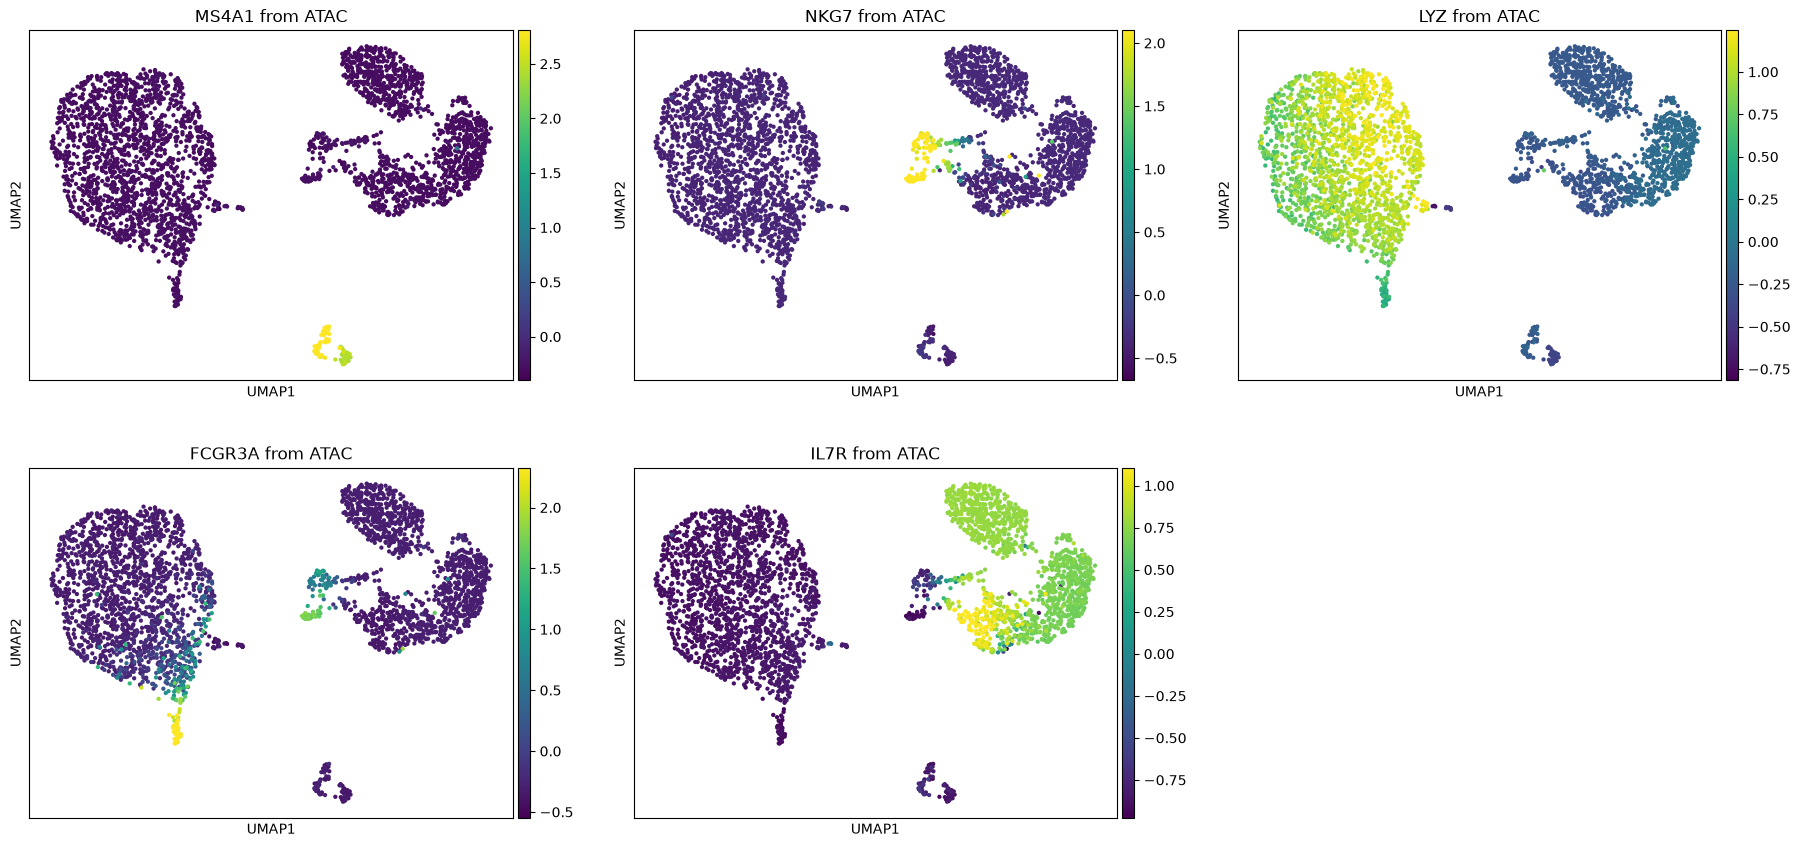

In [10]:
rna_t = test["rna"]
rna_t.layers["from_atac"] = cross_modal_predict(model, test["atac"], src_mod="atac", tgt_mod="rna", device=device)
rna_t.obsm["X_univi"] = z_rna
sc.pp.neighbors(rna_t, use_rep="X_univi")
sc.tl.umap(rna_t, random_state=0)
genes = [g for g in ["MS4A1", "CD3D", "NKG7", "LYZ", "FCGR3A", "IL7R"] if g in rna_t.var_names]
sc.pl.umap(rna_t, color=genes, ncols=3, vmax="p99", cmap="viridis", title=[f"{g} observed" for g in genes])
sc.pl.umap(rna_t, color=genes, ncols=3, layer="from_atac", vmax="p99", cmap="viridis", title=[f"{g} from ATAC" for g in genes])